# Talegaon Farms — Sales Analytics & Business Intelligence
**Author:** Kaihkasha Parveen  
**Last Updated:** June 2026  
**Tools:** Python · Pandas · Matplotlib · XGBoost · Streamlit

---

## Project Overview
End-to-end analysis of 6 years of real sales data from Talegaon Farms, 
a Mumbai-based farm delivery company serving 60+ housing societies.

**Dataset:** 116,873 orders · 4,460+ unique customers · 42 products · 4 categories  
**Period:** June 2020 to June 2026

---

## Table of Contents
1. Data Loading & Cleaning
2. Exploratory Data Analysis (EDA)
3. Customer Segmentation (RFM Analysis)
4. Churn Prediction Model (XGBoost)
5. Business Insights & Recommendations

## 1. Data Loading & Cleaning

Loading 6 years of sales data from individual Excel master files, 
combining into one dataset, and cleaning for analysis.

**Steps performed:**
- Combined 6 annual Excel files using glob
- Removed PII columns (Mobile, Name, Tower, Flat)
- Filtered out Sample category and zero-value orders
- Handled missing values in Building and Customer_ID
- Identified and removed duplicate bulk order entry (Jan 2024, Crescent Bay)

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Combine all Excel files
files = glob.glob(r'C:\Users\ACC1\Desktop\Project\Big_Project\TF_Master_*.xlsx')
print("Files found:", len(files))

df_list = []
for file in files:
    df = pd.read_excel(file, engine='openpyxl')
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

# Clean
df = df.drop(columns=['Mobile', 'Tower', 'Flat'])
df = df.dropna(subset=['Building', 'Customer_ID'])
df = df[df['Category'] != 'Sample']
df = df[df['Order_Total'] > 0]
df = df.dropna(subset=['Order_Total'])

# Save name reference privately
name_reference = df[['Customer_ID', 'Name', 'Building']].drop_duplicates()
name_reference.to_csv(r'C:\Users\ACC1\Desktop\Project\Big_Project\customer_name_reference.csv', index=False)

# Drop Name and save clean file
df = df.drop(columns=['Name'])
df.to_csv(r'C:\Users\ACC1\Desktop\Project\Big_Project\talegaon_final_clean.csv', index=False)

print(df.shape)
print("Saved successfully")

Files found: 6
(116873, 14)
Saved successfully


**Result:** 116,873 clean orders ready for analysis  
Date range: June 2020 to June 2026  
4 categories · 42 products · 60+ housing societies

## 2. Exploratory Data Analysis (EDA)

### 2.1 Revenue by Category
Understanding which product categories drive the most revenue across 6 years.

Category
Dairy     94720756.54
Honey     17316298.30
Oils      15175799.62
Chivda     2728091.54
Name: Order_Total, dtype: float64


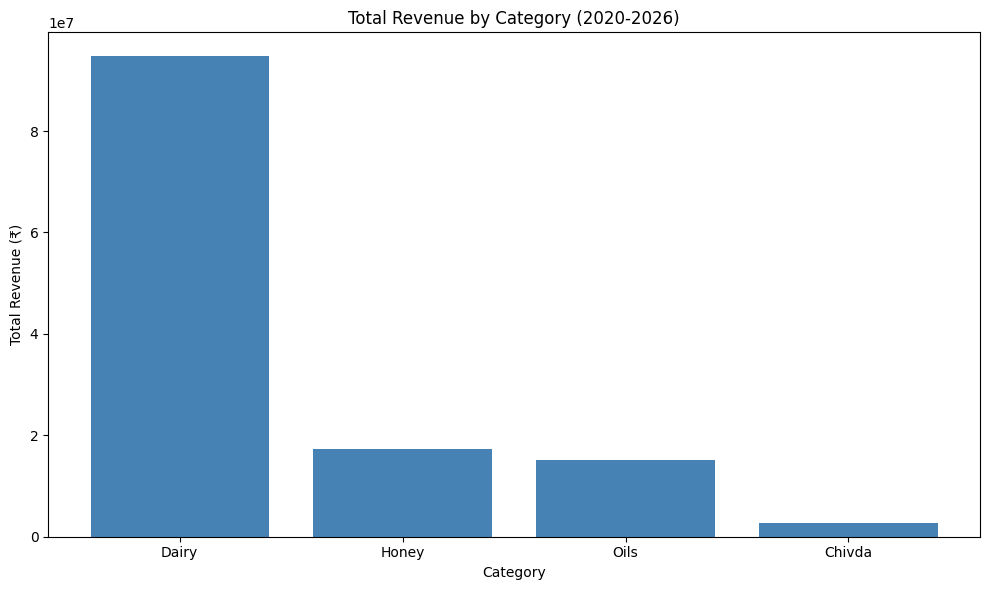

In [22]:
import matplotlib.pyplot as plt

# Revenue by category
category_revenue = df.groupby('Category')['Order_Total'].sum().sort_values(ascending=False)
print(category_revenue)

plt.figure(figsize=(10,6))
plt.bar(category_revenue.index, category_revenue.values, color='steelblue')
plt.title('Total Revenue by Category (2020-2026)')
plt.xlabel('Category')
plt.ylabel('Total Revenue (₹)')
plt.tight_layout()
plt.show()

**Insight:** Dairy accounts for 72% of total revenue — the business is 
heavily dependent on one category. Honey (13%) and Oils (11%) are distant 
second and third. Chivda contributes only 2% and has limited traction.

**Business Implication:** Any disruption to Dairy supply or demand 
directly threatens overall business health.

### 2.2 Top 10 Products by Revenue
Identifying which individual products generate the most revenue to understand 
product-level performance and concentration risk.


Product
Paneer 500g               25368671.57
Classic Cow Ghee 500ml    17500931.54
Paneer 250g               12768218.30
Curd                      12481081.69
A2 Gir Cow Ghee 500ml      9857663.61
White Butter 200g          8159500.94
Groundnut Oil 5 Ltr        3131795.80
Wild Honey 500g            2749429.08
Groundnut Oil 2 Ltr        2371965.90
Jamun Honey 500g           2272155.20
Name: Order_Total, dtype: float64


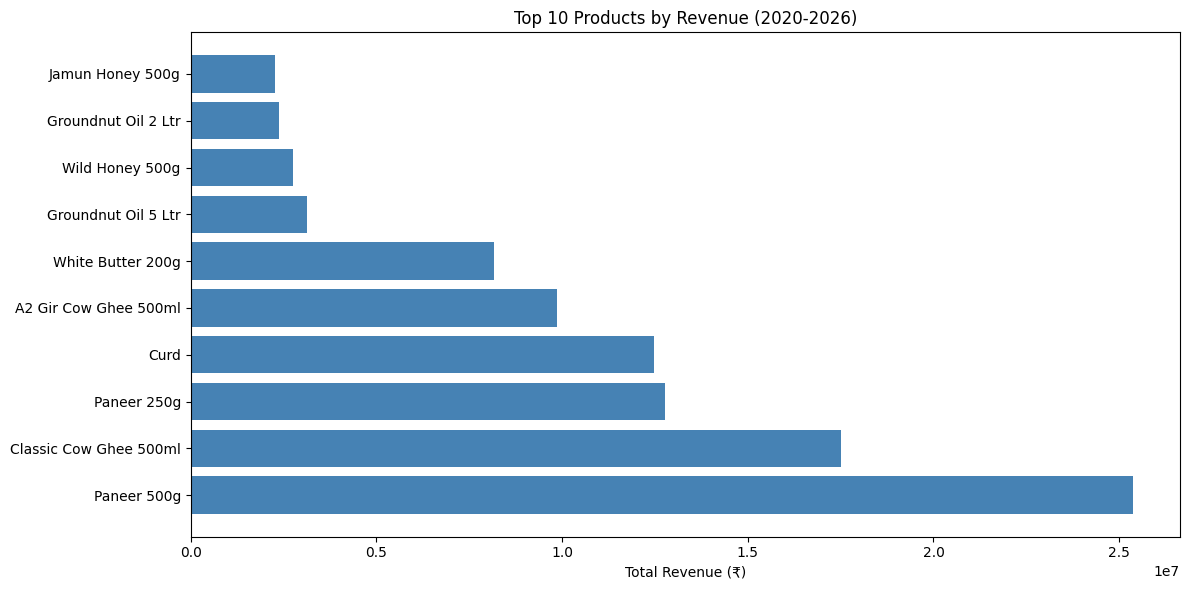

In [13]:
# Top 10 products by revenue
product_revenue = df.groupby('Product')['Order_Total'].sum().sort_values(ascending=False).head(10)
print(product_revenue)

plt.figure(figsize=(12,6))
plt.barh(product_revenue.index, product_revenue.values, color='steelblue')
plt.title('Top 10 Products by Revenue (2020-2026)')
plt.xlabel('Total Revenue (₹)')
plt.tight_layout()
plt.show()

**Insight:** Paneer 500g dominates at ₹2.53 Crore — nearly double the 
second highest product. The top 4 products are all Dairy, confirming 
category concentration at the product level as well.

**Business Implication:** Paneer 500g is the anchor product. Any pricing 
change, supply issue, or competitor offering on this single product has 
outsized impact on total revenue.

### 2.3 Monthly Revenue Trend (2020-2026)
Analysing how revenue has changed over 6 years to identify growth periods, 
seasonal patterns, and inflection points.

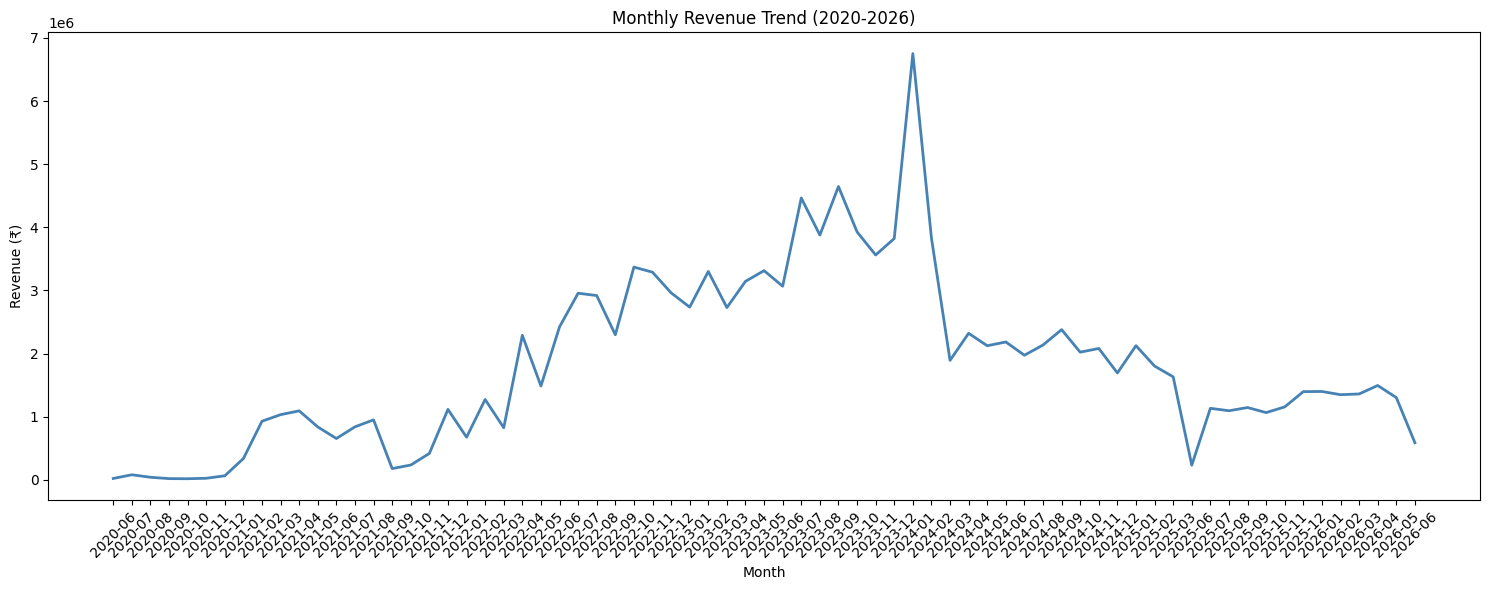

In [24]:
# Monthly revenue trend
df['Date'] = pd.to_datetime(df['Date'])
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Order_Total'].sum()

plt.figure(figsize=(15,6))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, color='steelblue', linewidth=2)
plt.title('Monthly Revenue Trend (2020-2026)')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Revenue grew consistently from June 2020 to mid-2023, 
peaking around ₹60-65 lakh per month. A data entry error in January 2024 
(bulk order at Crescent Bay — ₹37,502 entered 13 times) was identified 
and corrected. Post-2024, revenue dropped significantly and has not 
recovered to previous peak levels.

**Business Implication:** The business grew well for 3 years but has been 
in decline since late 2023. Understanding the cause of this decline is 
the most critical business question in this analysis.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('talegaon_final_clean.csv')
print(df.shape)

(113486, 14)


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_revenue_df = df.groupby(df['Date'].dt.to_period('M'))['Order_Total'].sum().reset_index()
monthly_revenue_df.columns = ['Month','Revenue']
print(monthly_revenue_df.nlargest(5,'Revenue'))

      Month    Revenue
43  2024-01  6752502.7
39  2023-09  4647065.2
37  2023-07  4465100.7
40  2023-10  3928279.8
38  2023-08  3877815.0


In [13]:
jan_2024 = df[df['Date'].dt.to_period('M')=='2024-01']
print("Total orders in Jan:",len(jan_2024))
print("\nTop 10 orders by vlaue:")
print(jan_2024.nlargest(10,'Order_Total')[['Date','Building','Category','Product','Qty','Order_Total']])

Total orders in Jan: 2630

Top 10 orders by vlaue:
            Date      Building Category                 Product  Qty  \
47618 2024-01-24  Crescent Bay    Dairy   A2 Gir Cow Ghee 500ml    6   
47620 2024-01-24  Crescent Bay    Dairy  Classic Cow Ghee 500ml   12   
47622 2024-01-24  Crescent Bay    Dairy                    Curd    3   
47623 2024-01-24  Crescent Bay    Dairy                    Curd    4   
47626 2024-01-24  Crescent Bay     Oils     Groundnut Oil 2 Ltr    3   
47628 2024-01-24  Crescent Bay     Oils     Groundnut Oil 5 Ltr    1   
47630 2024-01-24  Crescent Bay    Honey       Lychee Honey 250g    1   
47632 2024-01-24  Crescent Bay    Honey       Lychee Honey 500g    2   
47634 2024-01-24  Crescent Bay    Honey   Multiflora Honey 250g    1   
47636 2024-01-24  Crescent Bay    Honey   Multiflora Honey 500g    2   

       Order_Total  
47618      37502.1  
47620      37502.1  
47622      37502.1  
47623      37502.1  
47626      37502.1  
47628      37502.1  
47630    

In [14]:
# How many rows have exactly this suspicious value
suspicious = df[df['Order_Total'] == 37502.1]
print("Rows with suspicious value:", len(suspicious))
print("\nWhich dates:")
print(suspicious['Date'].value_counts().head(10))
print("\nWhich buildings:")
print(suspicious['Building'].value_counts().head(10))

Rows with suspicious value: 13

Which dates:
Date
2024-01-24    13
Name: count, dtype: int64

Which buildings:
Building
Crescent Bay    13
Name: count, dtype: int64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('talegaon_final_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
bulk_index = df[df['Order_Total']==37502.1].index
rows_to_drop = bulk_index[1:]
df=df.drop(rows_to_drop)
print(df.shape)

(113474, 14)


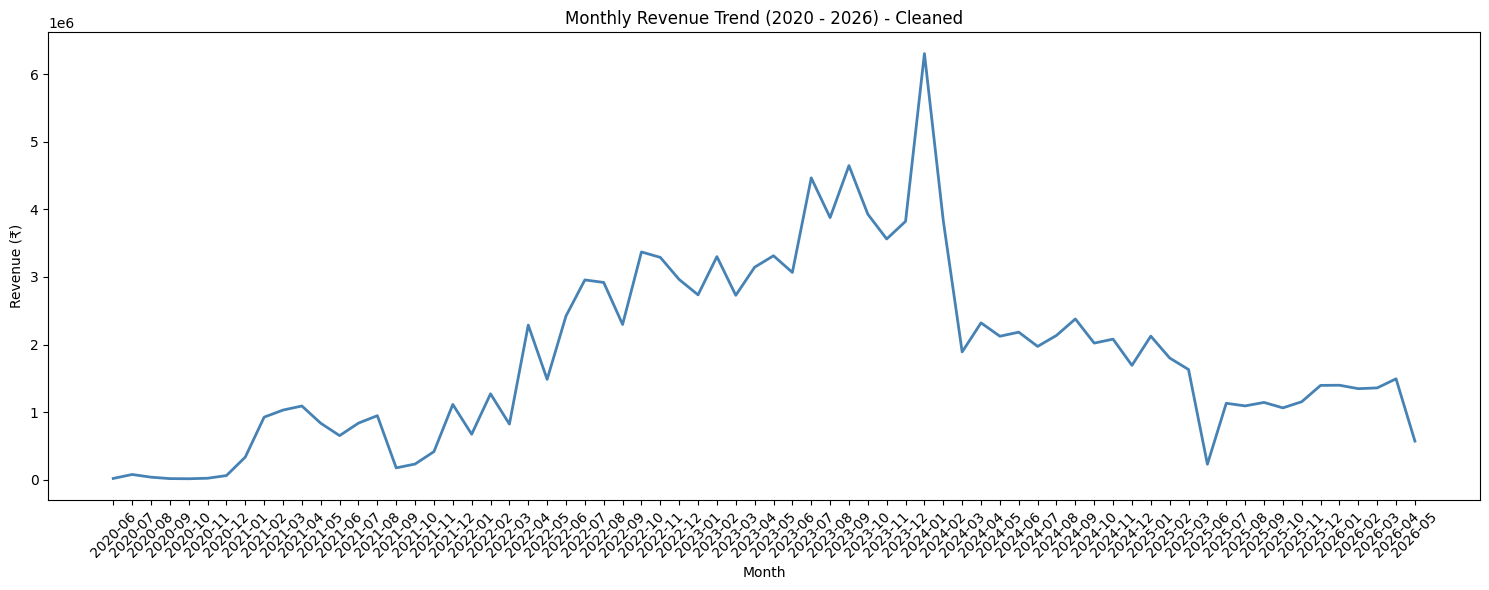

In [15]:
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Order_Total'].sum()
plt.figure(figsize=(15,6))
plt.plot(monthly_revenue.index.astype(str),monthly_revenue.values,color = 'steelblue',linewidth=2)
plt.title('Monthly Revenue Trend (2020 - 2026) - Cleaned')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Day_of_Week
Monday        2270851.99
Tuesday       5054312.40
Wednesday    32657257.31
Thursday      1923831.01
Friday        2206547.00
Saturday     76052298.09
Sunday        8008771.00
Name: Order_Total, dtype: float64


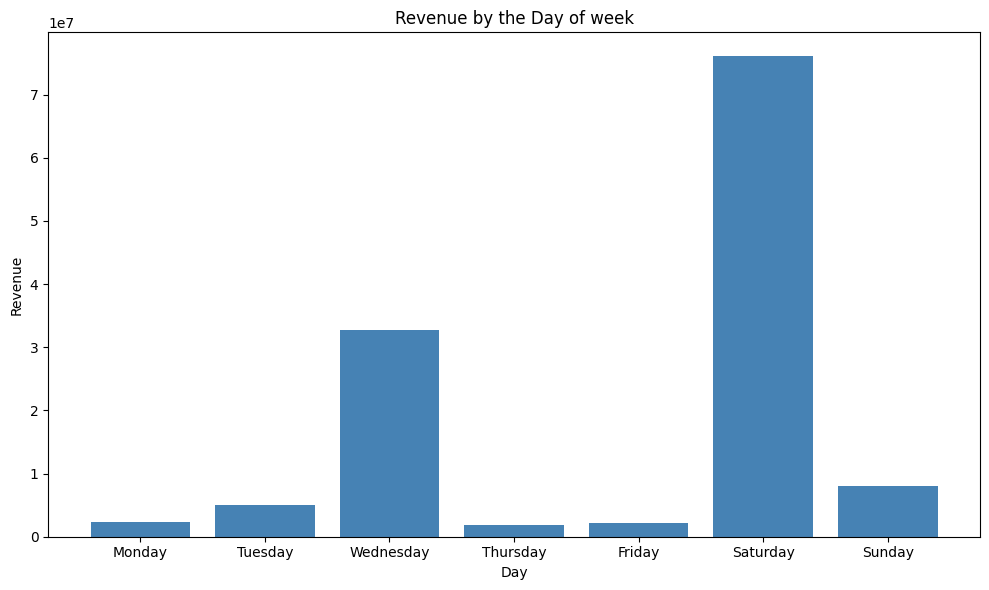

In [26]:
day_order = df.groupby('Day_of_Week')['Order_Total'].sum()
day_order = day_order.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print(day_order)
plt.figure(figsize=(10,6))
plt.bar(day_order.index,day_order.values,color='steelblue')
plt.title('Revenue by the Day of week')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

In [22]:
print(df['Day_of_Week'].unique())
print(df['Day_of_Week'].value_counts())

['Sunday' 'Saturday' 'Friday' 'Monday' 'Wednesday' 'Tuesday' 'Thursday']
Day_of_Week
Saturday     51872
Wednesday    31642
Sunday       10486
Tuesday       8285
Monday        4098
Friday        3681
Thursday      3410
Name: count, dtype: int64


Building
Crescent Bay          50083974.2
Rustomjee Seasons      6590061.0
Raheja Vivarea         4830391.0
Ashok Towers           4636624.0
Planet Godrej          3898355.0
Lodha Bellissimo       3644560.0
Lodha Park             3233209.0
Oberoi Exquisite       3020530.9
Raheja Imperia 1       2253460.0
Lodha World Towers     2232148.0
Marathon Era           1851040.0
Sumer Trinity          1483161.0
Phoenix Towers         1446628.0
Chaitanya Towers       1320518.0
Kanakia Paris          1162029.0
Name: Order_Total, dtype: float64


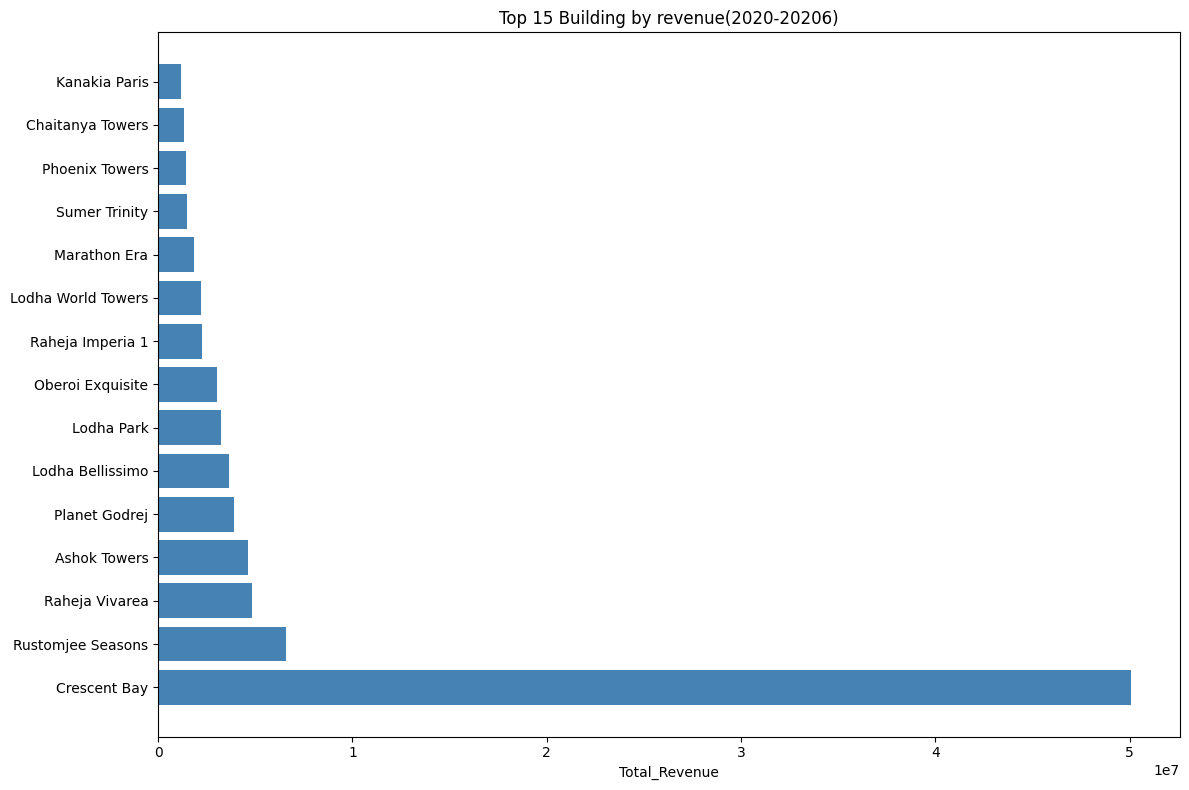

In [33]:
Building_revenue = df.groupby('Building')['Order_Total'].sum().sort_values(ascending=False).head(15)
print(Building_revenue)
plt.figure(figsize=(12,8))
plt.barh(Building_revenue.index,Building_revenue.values,color ='Steelblue')
plt.title('Top 15 Building by revenue(2020-20206)')
plt.xlabel('Total_Revenue')
plt.tight_layout()
plt.show()

In [36]:
# Filter last 12 months
recent = df[df['Date']>='2025-05-01']
recent_building = recent.groupby('Building')['Order_Total'].sum().sort_values(ascending=False).head(15)
print(recent_building)

Building
Crescent Bay              1163411.0
Rustomjee Seasons         1066782.0
Lodha Park                 739586.0
Ashok Towers               656445.0
Lodha Bellissimo           583505.0
Planet Godrej              572965.0
Raheja Vivarea             561609.0
Raheja Imperia 1           427750.0
Island City Center         338582.0
Chaitanya Towers           311448.0
Lodha The World Towers     306519.0
25 South                   269219.0
Phoenix Towers             238330.0
Marathon Era               218411.0
Kanakia Paris              182337.0
Name: Order_Total, dtype: float64


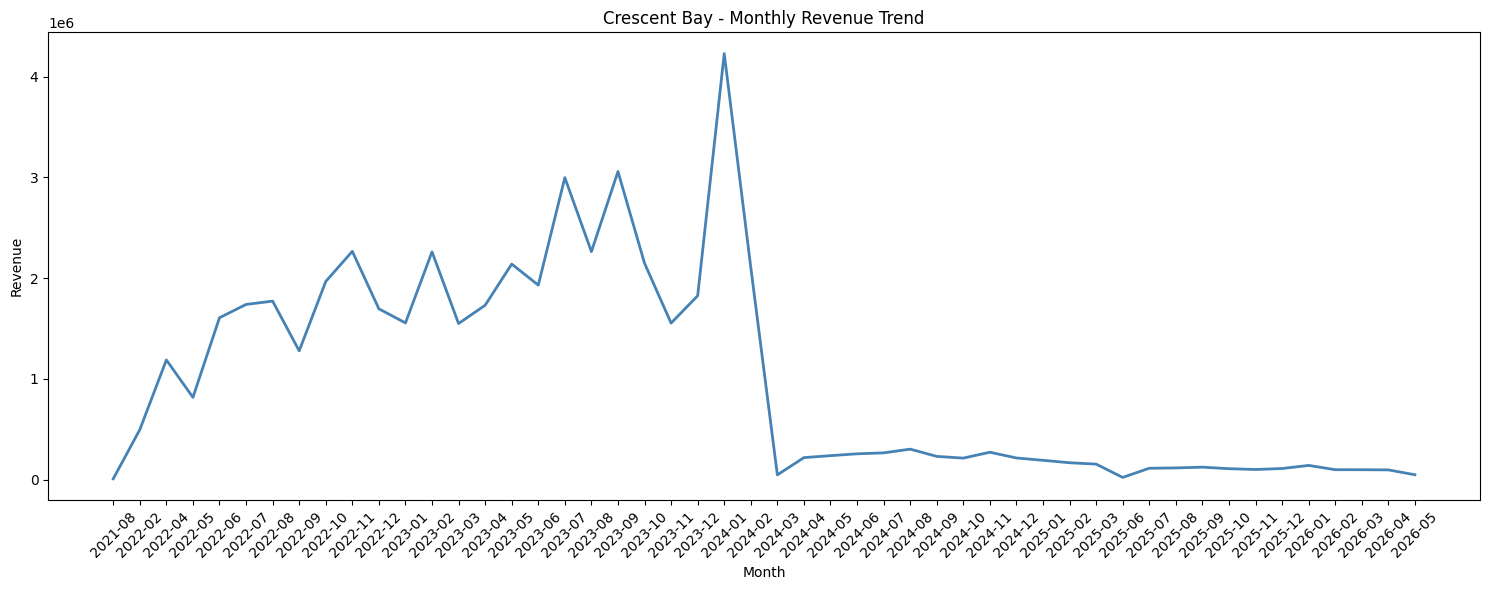

In [38]:
# Crescent Bay monthly revenue over time
cb = df[df['Building']=='Crescent Bay']
cb_monthly = cb.groupby(cb['Date'].dt.to_period('M'))['Order_Total'].sum()

plt.figure(figsize=(15,6))
plt.plot(cb_monthly.index.astype(str),cb_monthly.values,color='Steelblue',linewidth=2)
plt.title('Crescent Bay - Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('talegaon_final_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
bulk_index = df[df['Order_Total'] == 37502.1].index
df = df.drop(bulk_index[1:])
print(df.shape)

(113474, 14)


In [4]:
# Customer retention analysis
#Find first and last order of each customer
customer_activity = df.groupby('Customer_ID').agg(first_order = ('Date','min'),last_order = ('Date','max'),total_orders = ('Date','count'),total_revenue=('Order_Total','sum')).reset_index()
print(customer_activity.shape)
print(customer_activity.head())

(4460, 5)
      Customer_ID first_order last_order  total_orders  total_revenue
0       ADJ_APR26  2026-04-01 2026-04-01             2        60000.0
1  MOB_0172167995  2023-08-23 2023-08-23             1          600.0
2  MOB_1450401213  2023-09-30 2025-02-26            26        23520.0
3  MOB_1451994862  2026-01-27 2026-02-14             4          560.0
4  MOB_1504564834  2024-01-31 2024-02-03             2        15000.0


In [5]:
# Calculate days since last order
latest_date = df['Date'].max()
customer_activity['days_since_last_order'] = (latest_date - customer_activity['last_order']).dt.days

print("Latest date in data:", latest_date)
print(customer_activity[['Customer_ID', 'last_order', 'days_since_last_order']].head(10))


Latest date in data: 2026-05-13 00:00:00
      Customer_ID last_order  days_since_last_order
0       ADJ_APR26 2026-04-01                     42
1  MOB_0172167995 2023-08-23                    994
2  MOB_1450401213 2025-02-26                    441
3  MOB_1451994862 2026-02-14                     88
4  MOB_1504564834 2024-02-03                    830
5  MOB_1507461567 2025-01-04                    494
6  MOB_1509002374 2026-05-02                     11
7  MOB_1544069900 2025-12-02                    162
8  MOB_1589102341 2025-09-27                    228
9  MOB_2223058131 2021-05-02                   1837


segment
Churned    2443
Active     1399
At Risk     618
Name: count, dtype: int64


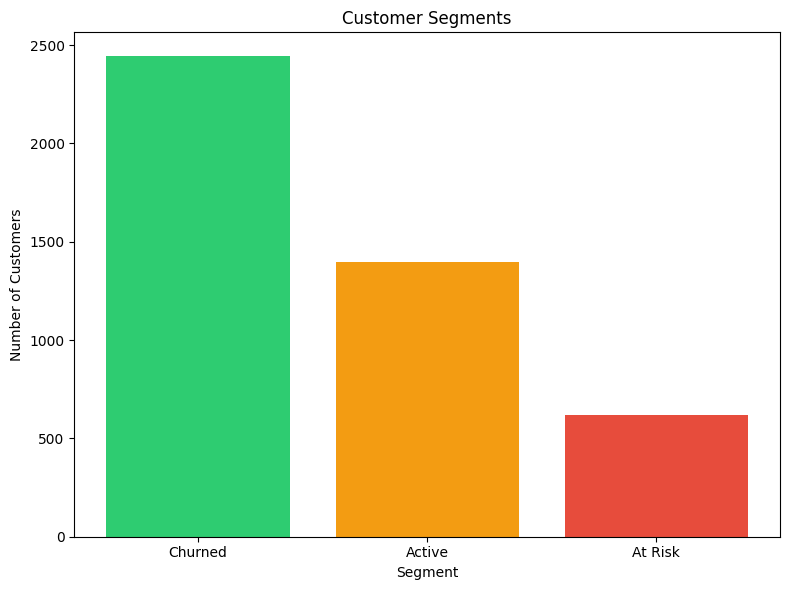

In [6]:
# Define customer segments
def segment_customer(days):
    if days <= 60:
        return 'Active'
    elif days <= 180:
        return 'At Risk'
    else:
        return 'Churned'

customer_activity['segment'] = customer_activity['days_since_last_order'].apply(segment_customer)

# Count each segment
print(customer_activity['segment'].value_counts())

# Plot
segment_counts = customer_activity['segment'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(8,6))
plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('talegaon_final_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
bulk_index = df[df['Order_Total']==37502.1].index
rows_to_drop = bulk_index[1:]
df=df.drop(rows_to_drop)
print(df.shape)

(113474, 14)


In [2]:
customer_activity = df.groupby('Customer_ID').agg(
    first_order=('Date', 'min'),
    last_order=('Date', 'max'),
    total_orders=('Date', 'count'),
    total_revenue=('Order_Total', 'sum')
).reset_index()

latest_date = df['Date'].max()
customer_activity['days_since_last_order'] = (latest_date - customer_activity['last_order']).dt.days

rfm = customer_activity[['Customer_ID', 'days_since_last_order', 'total_orders', 'total_revenue']].copy()
rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=3, labels=[3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=[1,2,3])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=3, labels=[1,2,3])

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def rfm_segment(score):
    if score >= 8:
        return 'Champion'
    elif score >= 6:
        return 'Loyal'
    elif score >= 4:
        return 'Potential'
    else:
        return 'Lost'

rfm['RFM_Segment'] = rfm['RFM_Score'].apply(rfm_segment)
print(rfm['RFM_Segment'].value_counts())

RFM_Segment
Potential    1452
Champion     1268
Loyal        1161
Lost          579
Name: count, dtype: int64


In [5]:
customer_activity['Churn'] = (customer_activity['days_since_last_order']>180).astype(int)
print(customer_activity['Churn'].value_counts())

Churn
1    2443
0    2017
Name: count, dtype: int64


In [8]:
features = ['Recency','Frequency','Monetary']
x = rfm[features]
y = customer_activity['Churn']
print(x.shape)
print(y.shape)

(4460, 3)
(4460,)


In [12]:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("Training rows:",x_train.shape[0])
print("Testing rows:",x_test.shape[0])


Training rows: 3568
Testing rows: 892



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
print('Model Traines Successfully')

Model Traines Successfully


In [16]:
from sklearn.metrics import accuracy_score,classification_report
y_pred = model.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nDetailed Report:")
print(classification_report(y_test,y_pred))

Accuracy: 0.9988789237668162

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       374
           1       1.00      1.00      1.00       518

    accuracy                           1.00       892
   macro avg       1.00      1.00      1.00       892
weighted avg       1.00      1.00      1.00       892



In [18]:
features = ['Frequency', 'Monetary']
X = rfm[features]
y = customer_activity['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6995515695067265

Detailed Report:
              precision    recall  f1-score   support

           0       0.76      0.42      0.54       374
           1       0.68      0.90      0.78       518

    accuracy                           0.70       892
   macro avg       0.72      0.66      0.66       892
weighted avg       0.71      0.70      0.68       892



In [23]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 131.3 kB/s eta 0:12:55
   ---------------------------------------- 0.1/101.7 MB 450.6 kB/s eta 0:03:46
   ---------------------------------------- 0.7/101.7 MB 2.2 MB/s eta 0:00:46
   ---------------------------------------- 1.2/101.7 MB 3.6 MB/s eta 0:00:29
    --------------------------------------- 1.8/101.7 MB 4.6 MB/s eta 0:00:22
    --------------------------------------- 2.3/101.7 MB 5.3 MB/s eta 0:00:19
   - --------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nDetailed Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.7230941704035875

Detailed Report:
              precision    recall  f1-score   support

           0       0.66      0.68      0.67       374
           1       0.77      0.75      0.76       518

    accuracy                           0.72       892
   macro avg       0.72      0.72      0.72       892
weighted avg       0.72      0.72      0.72       892



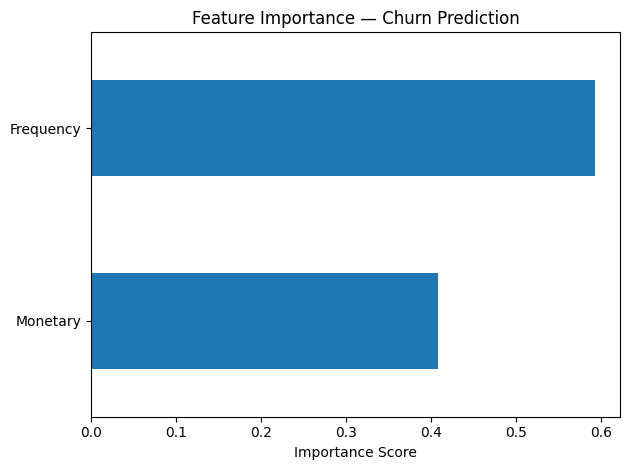

In [26]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(xgb_model.feature_importances_, index=features)
feature_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance — Churn Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('talegaon_final_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
bulk_index = df[df['Order_Total']==37502.1].index
rows_to_drop = bulk_index[1:]
df=df.drop(rows_to_drop)
print(df.shape)

(113474, 14)


In [2]:
customer_activity = df.groupby('Customer_ID').agg(
    first_order=('Date', 'min'),
    last_order=('Date', 'max'),
    total_orders=('Date', 'count'),
    total_revenue=('Order_Total', 'sum')
).reset_index()

latest_date = df['Date'].max()
customer_activity['days_since_last_order'] = (latest_date - customer_activity['last_order']).dt.days
customer_activity['churn'] = (customer_activity['days_since_last_order'] > 180).astype(int)

rfm = customer_activity[['Customer_ID', 'days_since_last_order', 'total_orders', 'total_revenue']].copy()
rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=3, labels=[3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=[1,2,3])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=3, labels=[1,2,3])

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def rfm_segment(score):
    if score >= 8:
        return 'Champion'
    elif score >= 6:
        return 'Loyal'
    elif score >= 4:
        return 'Potential'
    else:
        return 'Lost'

rfm['RFM_Segment'] = rfm['RFM_Score'].apply(rfm_segment)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

features = ['Frequency', 'Monetary']
X = rfm[features]
y = customer_activity['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

print("Model ready. Accuracy:", accuracy_score(y_test, xgb_model.predict(X_test)))
print("RFM segments:", rfm['RFM_Segment'].value_counts().to_dict())

Model ready. Accuracy: 0.7230941704035875
RFM segments: {'Potential': 1452, 'Champion': 1268, 'Loyal': 1161, 'Lost': 579}


2026-06-08 16:57:50.677 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-08 16:57:50.684 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-08 16:57:50.686 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-08 16:57:51.907 
  command:

    streamlit run C:\Users\ACC1\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-08 16:57:51.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-08 16:57:51.909 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-08 16:57:51.912 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-08 16:57:52.42

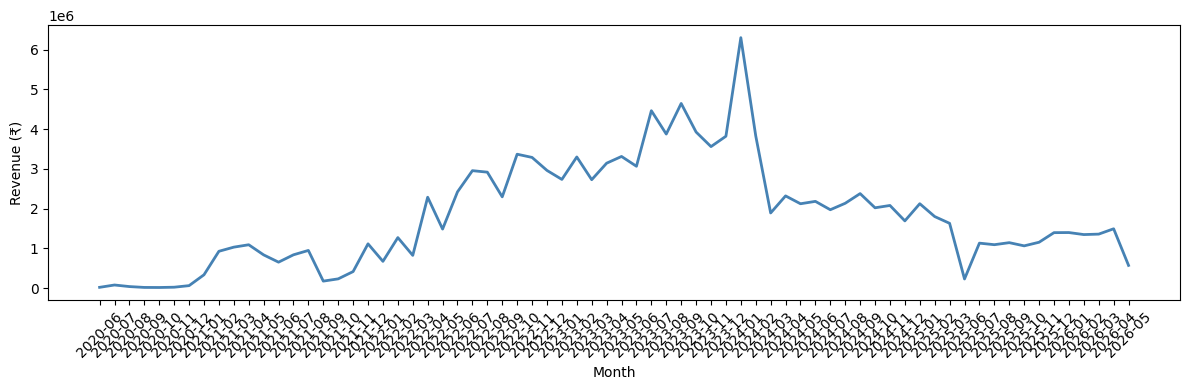

In [3]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import glob

# Load and prepare data
@st.cache_data
def load_data():
    files = glob.glob('*.xlsx')
    df = pd.concat([pd.read_excel(f) for f in files], ignore_index=True)
    df = df.drop(columns=['Mobile', 'Tower', 'Flat', 'Name'], errors='ignore')
    df = df.dropna(subset=['Building', 'Customer_ID'])
    df = df[df['Category'] != 'Sample']
    df = df[df['Order_Total'] > 0]
    df = df.dropna(subset=['Order_Total'])
    bulk_index = df[df['Order_Total'] == 37502.1].index
    df = df.drop(bulk_index[1:])
    df['Date'] = pd.to_datetime(df['Date'])
    return df

df = load_data()

# Sidebar
st.sidebar.title("Talégaon Farms")
st.sidebar.markdown("Sales Analytics Dashboard")
page = st.sidebar.selectbox("Select Page", [
    "Overview", 
    "Product Analysis", 
    "Customer Segments",
    "Churn Prediction"
])

# Overview page
if page == "Overview":
    st.title("Business Overview")
    
    col1, col2, col3 = st.columns(3)
    col1.metric("Total Revenue", f"₹{df['Order_Total'].sum()/10000000:.1f} Cr")
    col2.metric("Total Orders", f"{len(df):,}")
    col3.metric("Unique Customers", f"{df['Customer_ID'].nunique():,}")
    
    st.subheader("Monthly Revenue Trend")
    monthly = df.groupby(df['Date'].dt.to_period('M'))['Order_Total'].sum()
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(monthly.index.astype(str), monthly.values, color='steelblue', linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('Revenue (₹)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    st.pyplot(fig)

# Product Analysis page
elif page == "Product Analysis":
    st.title("Product Analysis")
    
    st.subheader("Revenue by Category")
    cat_rev = df.groupby('Category')['Order_Total'].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(cat_rev.index, cat_rev.values, color='steelblue')
    ax.set_xlabel('Category')
    ax.set_ylabel('Revenue (₹)')
    plt.tight_layout()
    st.pyplot(fig)
    
    st.subheader("Top 10 Products by Revenue")
    prod_rev = df.groupby('Product')['Order_Total'].sum().sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(10,5))
    ax.barh(prod_rev.index, prod_rev.values, color='steelblue')
    ax.set_xlabel('Revenue (₹)')
    plt.tight_layout()
    st.pyplot(fig)

# Customer Segments page
elif page == "Customer Segments":
    st.title("Customer Segmentation")
    
    customer_activity = df.groupby('Customer_ID').agg(
        total_orders=('Date', 'count'),
        total_revenue=('Order_Total', 'sum'),
        last_order=('Date', 'max')
    ).reset_index()
    
    latest_date = df['Date'].max()
    customer_activity['days_since_last_order'] = (latest_date - customer_activity['last_order']).dt.days
    
    rfm = customer_activity[['Customer_ID', 'days_since_last_order', 'total_orders', 'total_revenue']].copy()
    rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']
    
    rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=3, labels=[3,2,1])
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=[1,2,3])
    rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=3, labels=[1,2,3])
    rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
    
    def rfm_segment(score):
        if score >= 8:
            return 'Champion'
        elif score >= 6:
            return 'Loyal'
        elif score >= 4:
            return 'Potential'
        else:
            return 'Lost'
    
    rfm['RFM_Segment'] = rfm['RFM_Score'].apply(rfm_segment)
    
    seg_counts = rfm['RFM_Segment'].value_counts()
    colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(seg_counts.index, seg_counts.values, color=colors)
    ax.set_xlabel('Segment')
    ax.set_ylabel('Number of Customers')
    plt.tight_layout()
    st.pyplot(fig)
    
    st.dataframe(rfm[['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'RFM_Segment']].head(20))

# Churn Prediction page
elif page == "Churn Prediction":
    st.title("Churn Prediction")
    
    customer_activity = df.groupby('Customer_ID').agg(
        total_orders=('Date', 'count'),
        total_revenue=('Order_Total', 'sum'),
        last_order=('Date', 'max')
    ).reset_index()
    
    latest_date = df['Date'].max()
    customer_activity['days_since_last_order'] = (latest_date - customer_activity['last_order']).dt.days
    customer_activity['churn'] = (customer_activity['days_since_last_order'] > 180).astype(int)
    
    rfm = customer_activity[['Customer_ID', 'days_since_last_order', 'total_orders', 'total_revenue']].copy()
    rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']
    
    X = rfm[['Frequency', 'Monetary']]
    y = customer_activity['churn']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = XGBClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    st.subheader("Predict Customer Churn")
    freq = st.slider("Order Frequency", 1, 100, 10)
    monetary = st.slider("Total Spend (₹)", 100, 100000, 5000)
    
    prediction = model.predict([[freq, monetary]])
    probability = model.predict_proba([[freq, monetary]])[0][1]
    
    if prediction[0] == 1:
        st.error(f"⚠️ High churn risk — {probability:.0%} probability of churning")
    else:
        st.success(f"✅ Low churn risk — {probability:.0%} probability of churning")